# Survival Analysis for LGD model 

Various steps used by banks to derive the loss rate for unresolved cases 

Historical average 
Advance techniques such as Survival technique 
Cap the facilities to a certain amount based on the historical data  
conservattive approach , unresolved will have maximum loss at the time of default 


Calculate all the defaulted cases for suvival model . This has to be done for all defaults only since it is a LGD model and would consider below specific points :
1. Currently under recovery process
2. Dataset is for unsecured retail customers
3. Banks want to know about the survival probability of the defaulter customers which are not part of the LGD model
   

Steps involved :

1. Pre processing for Survival dataset
2. Understanding the dataset
3. Apply the algorithm based on the dataset description 
4. filter for obervations which have recovery vector 
5. for the max recovery time for all observations and select the time to inlcude maximum observations
6. Only non negative cash flows and recover rates are inlcuded 


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyspark
from pyspark.sql import functions as F
from functools import reduce 
#from pyspark.sql.functions import when,col,avg

# Immputing Missing data

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from numpy.linalg import cond
from sklearn.experimental import enable_iterative_imputer  # Enable IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# for model application 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# for visual representation , understanding data 

import matplotlib.pyplot as plt D
import seaborn as sns 
import scipy.stats as stats
# from skimpy import skim # package issues # version control changes needed , keep it for later post this development
# from pandas_profiling import ProfileReport # version control changes needed , keep it for later post this development 


# display 
pd.set_option('display.max_rows',1000)


In [3]:
from pyspark.sql import SparkSession 
spark = SparkSession.builder.appName("survival").getOrCreate()

In [ ]:
spark

In [4]:
os.chdir(r'C:\Users\prashant\Modelling\Data')

In [5]:
# default dataset 
dd = spark.read.option('header',True)\
               .option('delimiter',',')\
               .option('inferSchema',True)\
               .csv(r'C:\Users\prashant\Modelling\Data\default_data.csv')

In [70]:
# get the main loan dataset
lnd = spark.read.option('header',True)\
                .option('delimiter',',')\
                .option('inferSchema',True)\
                .csv(r'C:\Users\prashant\Modelling\Data\loan_Data.csv')

In [7]:
# get the  LGD  with account level recovery amounts 
lgd = spark.read.option('header',True)\
                .option('delimiter',',')\
                .option('inferSchema',True)\
                .csv(r'C:\Users\prashant\Modelling\Data\loss_Data.csv')

In [8]:
# to assess the shape of dataframe 

def spark_shape(self):
    return(self.count(),len(self.columns))
pyspark.sql.dataframe.DataFrame.shape = spark_shape

In [9]:
#dd = dd.filter(F.col('default_time') == 1)
dd = dd.filter(F.col('default_time') == 1)\
         .withColumn('EAD',F.col('balance_time'))

In [10]:
# check for final default cases
dd = dd.select(['id'\
                ,'first_time'\
                ,'mat_time'\
                ,'balance_time'\
                ,'LTV_time'\
                ,'interest_rate_time'\
                ,'rate_time'\
                ,'hpi_time'\
                ,'gdp_time'\
                ,'balance_orig_time'\
                ,'default_time'\
                ,'EAD'])

In [11]:
lgd = lgd.filter(F.col('default_time') == 1)\
         .withColumn('EAD',F.col('balance_time'))

join default dataset with loss dataset to get the recoveries , to assess the defaults for which recovery process is still underway this is needed since the recoveries dataset will be added back for Cox regression post estimation of coeffecients using ulitmate or partial recoveries dataset

Features used for final product :
check ones which are binary 
1. Mortgage/product month when defaulted
2. Original month/term 
3. LTV
4. Int rate/int_rate
5. hpi
6. gdp
7. FICO
8. ID
9. Original Balance/loan_amnt 
10. Left Balance/total_pymnt - 



From Loan dataset : 

1. Prod_m_def
2. term
3. balance_time
4. LTV(concatenate with Default data and fill the values)
5. int_rate 
6. hpi
7. gdp
8. fico(concatenate with Default data and fill the values)
9. id
10. funded_amnt
11. total_rec_prncp + total_rec_int + total_rec_late_fee + recoveries



In [12]:
# For no recovery cases LGD would be 1 , thereore post joining the LGD data and DD data need to fill the missing vaulues with 1
cols_dd = ['id','first_time','mat_time','balance_time','balance_orig_time','EAD','hpi_time','gdp_time','LTV_time','interest_rate_time','default_time']
dd_lgd_ead = dd.filter(F.col('default_time') == 1)\
               .join(lgd,dd['id'] == lgd['id'],'left')\
               .select(*[dd[col] for col in cols_dd],lgd['lgd_time'].alias('LGD'))


In [13]:
dd_lgd_ead = dd_lgd_ead.withColumnRenamed('interest_rate_time','int_rate_time')

In [169]:
dd_lgd_ead.where(dd_lgd_ead.LGD.isNull()).count()

0

In [14]:
# Filling up null LGD values with 1 since there are all non recovery cases therefore total loss for the bank 
lgd_fill = 1
dd_lgd_ead = dd_lgd_ead.fillna({'LGD' : lgd_fill})

In [157]:
dd_lgd_ead.printSchema()

root
 |-- id: integer (nullable = true)
 |-- first_time: integer (nullable = true)
 |-- mat_time: integer (nullable = true)
 |-- balance_time: double (nullable = true)
 |-- balance_orig_time: double (nullable = true)
 |-- EAD: double (nullable = true)
 |-- hpi_time: double (nullable = true)
 |-- gdp_time: double (nullable = true)
 |-- LTV_time: double (nullable = true)
 |-- int_rate_time: double (nullable = true)
 |-- default_time: integer (nullable = true)
 |-- LGD: double (nullable = false)



## To get LGD and EAD for all defaulted cases 

In [71]:
# data processing for lnd 
lnd = lnd.withColumn("term", F.regexp_replace("term", "months", ""))

# Data Manipulations to Loan dataset 

In [72]:
# check for missing values in mths_since_last_delinq for default cases and replace  the missing with mths_since_last_record 
# since there is no data on vintage age of the portfolio
lnd = lnd.filter(F.col('loan_status') == 'Default')\
         .withColumn('mths_since_last_delinq',F.when(F.col('mths_since_last_delinq').isNull(),F.col('mths_since_last_record')).\
         otherwise(F.col('mths_since_last_delinq')))

In [74]:
lnd.filter(F.col('mths_since_last_delinq').isNull()).count()

360

In [75]:
lnd = lnd.withColumn("mths_since_last_delinq", lnd["mths_since_last_delinq"].cast('integer'))\
         .withColumn("term", lnd["term"].cast("float"))     

# Understanding data ditribution for finalized vectors 
Since pyspark doesnt support QQ plots therefore converting spark dataframe to pandas 

In [18]:
dd_lgd_ead_p = dd_lgd_ead.toPandas()

In [ ]:
dd_lgd_ead_p.head(10)

Text(0.5, 1.0, 'QQ Plot for LGD')

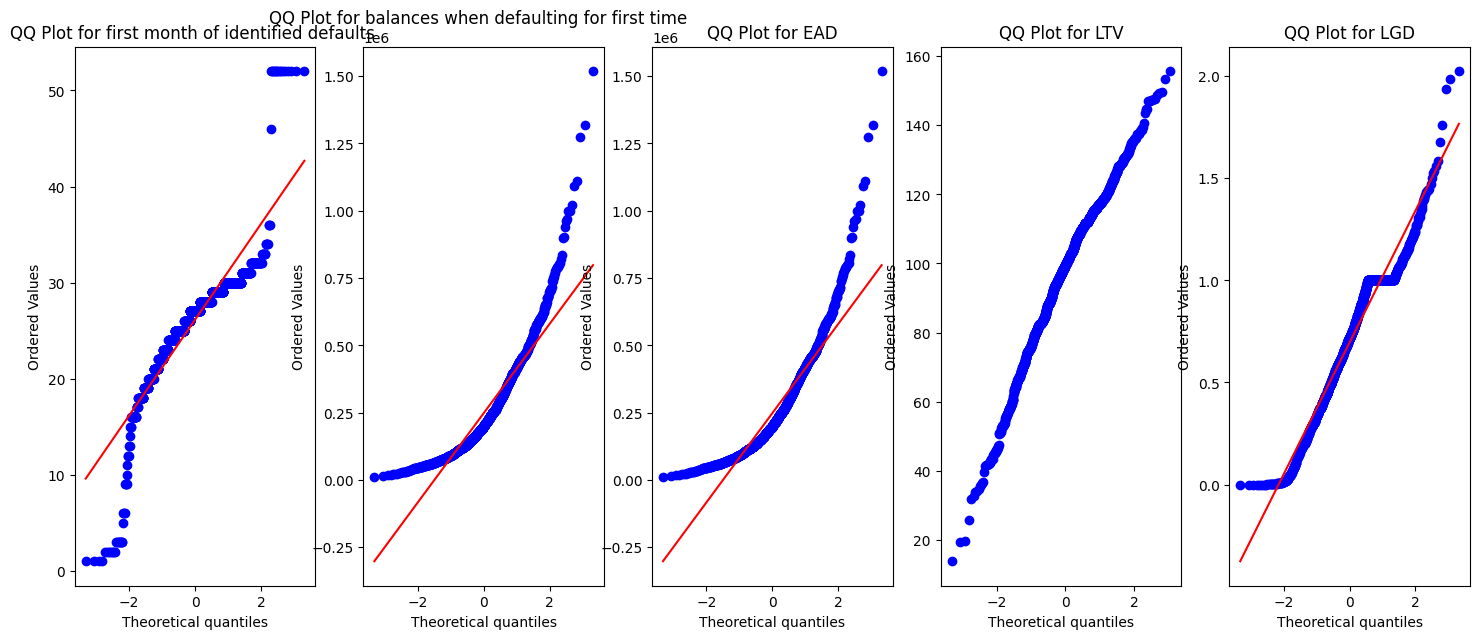

In [158]:
# QQ plots

# Data distribution  visual Test -Step 1 
# Creating QQ plots 
fig, axs = plt.subplots(1, 5, figsize=(18, 7))
stats.probplot(dd_lgd_ead_p['first_time'], dist="norm", plot=axs[0])
axs[0].set_title('QQ Plot for first month of identified defaults ')
stats.probplot(dd_lgd_ead_p['balance_time'], dist="norm", plot=axs[1])
axs[1].set_title('QQ Plot for balances when defaulting for first time  ')
stats.probplot(dd_lgd_ead_p['EAD'], dist="norm", plot=axs[2])
axs[2].set_title('QQ Plot for EAD')
stats.probplot(dd_lgd_ead_p['LTV_time'], dist="norm", plot=axs[3])
axs[3].set_title('QQ Plot for LTV')
stats.probplot(dd_lgd_ead_p['LGD'], dist="norm", plot=axs[4])
axs[4].set_title('QQ Plot for LGD')

(0.0, 1.0, 0.0, 1.0)

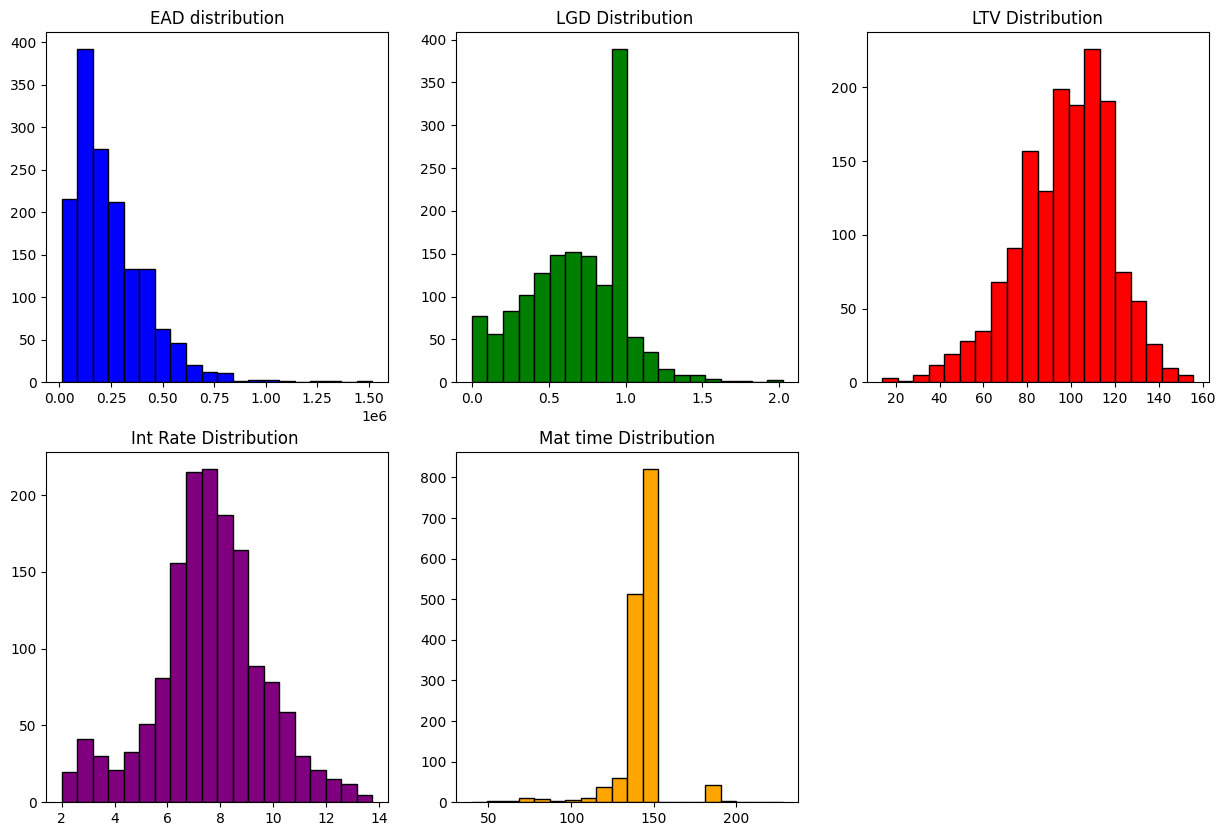

In [159]:
# Trend Analysis on selected variables using Line charts
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(dd_lgd_ead_p['EAD'], bins=20, color='blue', edgecolor='black')
axes[0, 0].set_title('EAD distribution')

axes[0, 1].hist(dd_lgd_ead_p['LGD'], bins=20, color='green', edgecolor='black')
axes[0, 1].set_title('LGD Distribution ')

axes[0, 2].hist(dd_lgd_ead_p['LTV_time'], bins=20, color='red', edgecolor='black')
axes[0, 2].set_title('LTV Distribution')
    
axes[1, 0].hist(dd_lgd_ead_p['int_rate_time'], bins=20, color='purple', edgecolor='black')
axes[1, 0].set_title('Int Rate Distribution ')

axes[1, 1].hist(dd_lgd_ead_p['mat_time'], bins=20, color='orange', edgecolor='black')
axes[1, 1].set_title('Mat time Distribution')

axes[1,2].axis('off')

# Check for outlier and distribution using below visuals 
1. Box plot 
2. Scatter plot 


Text(0.5, 1.0, 'Box Plot - EAD distribution and Opening balances')

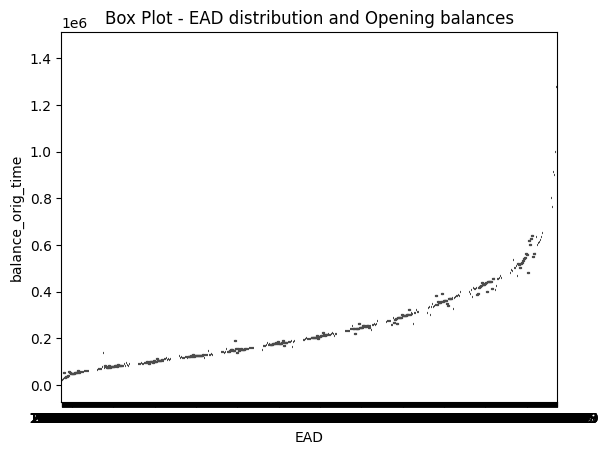

In [160]:
# All Plots for EAD variable 
sns.boxplot(x=dd_lgd_ead_p['EAD'],y=dd_lgd_ead_p['balance_orig_time'],data=dd_lgd_ead_p,color='red')
plt.title('Box Plot - EAD distribution and Opening balances')

Text(0.5, 1.0, 'Scatter Plot - EAD distribution and LTV ')

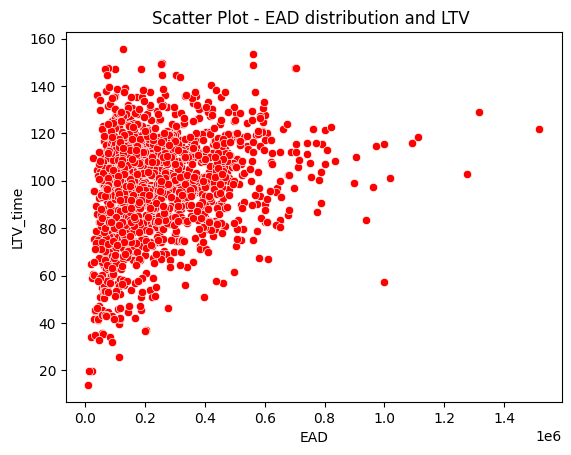

In [178]:
#Check monotonicity of EAD for bank and the balances when loan was originated . This is to know how has the default moved w.r.t origination balances
sns.scatterplot(x=dd_lgd_ead_p['EAD'],y=dd_lgd_ead_p['LTV_time'],color='red')
plt.title('Scatter Plot - EAD distribution and LTV ')



Text(0.5, 1.0, 'Scatter Plot - EAD distribution and Opening Balance ')

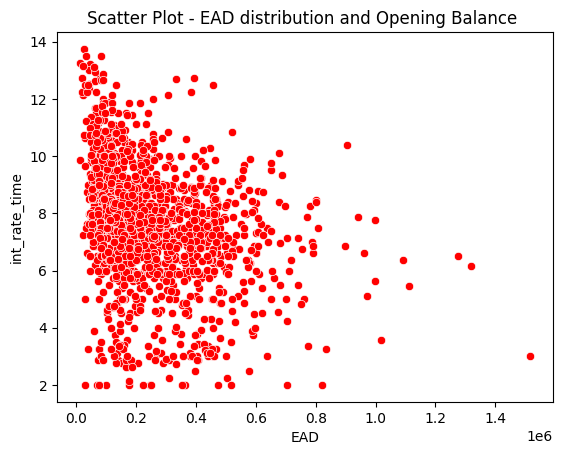

In [162]:
#Check monotonicity of EAD with int rate to see how are exposures moving w.r.t change in int rates
sns.scatterplot(x=dd_lgd_ead_p['EAD'],y=dd_lgd_ead_p['int_rate_time'],color='red')
plt.title('Scatter Plot - EAD distribution and Opening Balance ')

In [41]:
#converting to pandas to execute Shapiro Wilk test and summary statistics of final variables 
lnd_p = lnd.toPandas()
lnd_p.describe()



,_c0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,annual_inc,mths_since_last_delinq
count,832.000000,8.320000e+02,8.320000e+02,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,472.000000
mean,286510.856971,1.762283e+07,1.958943e+07,15284.885817,15284.885817,15279.967293,45.865383,16.136394,455.537296,65611.847500,41.529661
std,121121.621154,1.022619e+07,1.078452e+07,8311.439119,8311.439119,8309.008955,11.815757,4.032109,239.789217,40715.274019,29.123924
min,318.000000,6.093710e+05,7.816300e+05,1000.000000,1000.000000,1000.000000,36.000000,6.490000,33.210000,10000.000000,1.000000
25%,196137.750000,9.388168e+06,1.088521e+07,9600.000000,9600.000000,9600.000000,36.000000,13.350000,288.457500,40000.000000,17.000000
50%,314506.500000,1.624678e+07,1.829457e+07,13675.000000,13675.000000,13675.000000,36.000000,15.800000,398.520000,56254.000000,36.000000
75%,386295.000000,2.519613e+07,2.763922e+07,20000.000000,20000.000000,20000.000000,60.000000,18.990000,580.302500,78653.000000,63.000000
max,465876.000000,3.783081e+07,4.059367e+07,35000.000000,35000.000000,35000.000000,60.000000,26.060000,1300.200000,375000.000000,118.000000


In [187]:
# shapiro Wilk Test
columns_lnd = ['loan_amnt','funded_amnt','funded_amnt_inv','term','int_rate','installment','annual_inc','mths_since_last_delinq']
results_norm = {}
for i in columns_lnd:
    stat,p_value = stats.shapiro(lnd_p[i])
    results_norm[i] = {'statistic':stat,'p_value':p_value}    

In [188]:
for column,result in results_norm.items():
    print(f"Column: {column}")
    print(f"  Shapiro-Wilk Statistic: {result['statistic']:.4f}")
    print(f"  p-value: {result['p_value']:.4f}")
    if result['p_value'] > 5:
        print('data has normal distribution')
    else:
        print('data does not have normal distribution')

Column: loan_amnt
  Shapiro-Wilk Statistic: 0.9425
  p-value: 0.0000
data does not have normal distribution
Column: funded_amnt
  Shapiro-Wilk Statistic: 0.9425
  p-value: 0.0000
data does not have normal distribution
Column: funded_amnt_inv
  Shapiro-Wilk Statistic: 0.9425
  p-value: 0.0000
data does not have normal distribution
Column: term
  Shapiro-Wilk Statistic: nan
  p-value: 1.0000
data does not have normal distribution
Column: int_rate
  Shapiro-Wilk Statistic: 0.9910
  p-value: 0.0001
data does not have normal distribution
Column: installment
  Shapiro-Wilk Statistic: 0.9379
  p-value: 0.0000
data does not have normal distribution
Column: annual_inc
  Shapiro-Wilk Statistic: 0.7765
  p-value: 0.0000
data does not have normal distribution
Column: mths_since_last_delinq
  Shapiro-Wilk Statistic: nan
  p-value: 1.0000
data does not have normal distribution


In [76]:
# replace the col values with KNN algorithm , change K as necessary (convert to pandas, spark doesnt work)
imputer = KNNImputer(n_neighbors=2)
lnd_p['mths_since_last_delinq'] = imputer.fit_transform(lnd_p[['mths_since_last_delinq']])

In [77]:
imputed_data = imputer.fit_transform(lnd_p[['mths_since_last_delinq']])
id_knn1 = imputed_data.mean()

In [78]:
id_knn1

41.52966101694915

# we can conclude that data does not follow normal distribution

# checking these option for Missing data replacement:
1. Minimum of vector
2. Maximum of vector
3. Average of Vector
4. Median of Vector
5. MICE
6. KNN(convert to pandas since spark doesnt support 1D to 2D conversion)
7. Linear Prediction 

In [79]:

# filling up the missing values of mths_since_last_delinq  with the average/min/max values , the selection of the values will be based on best fit measures 
m_del_avg = lnd.select(F.mean(F.col('mths_since_last_delinq'))).first()[0]
m_del_min = lnd.select(F.min(F.col('mths_since_last_delinq'))).first()[0]
m_del_max = lnd.select(F.max(F.col('mths_since_last_delinq'))).first()[0]
m_del_med = lnd.approxQuantile('mths_since_last_delinq',[0.50],0.01)[0]

# replace the col values with avereage 
lnd_avg = lnd.fillna({'mths_since_last_delinq' : m_del_avg})

# replace the col values with median 
lnd_med = lnd.fillna({'mths_since_last_delinq' : m_del_med})


# replace the col values with min 
lnd_min = lnd.fillna({'mths_since_last_delinq' : m_del_min})


# replace the col values with max 
lnd_max = lnd.fillna({'mths_since_last_delinq' : m_del_max})



# Imputing missing values using Linear Prediction. Not using MICE since the logic requires the data to be 

1. Noisy 
2. Not Linearly related , which is proven otherwise in scatter plot and QQ plots above

Since this is linear data , therefore restricting the application to suggested 6 methods.

Before applying Linear prediction for missing value imputation , checking for corelation using 

1.Heatmaps
2.Guassian Copulas(Good for checking corelation for tail distribution)
3.Corelation Matrix(Pearson)

In [23]:
# selecting the columns 
selected_columns = ['loan_amnt','funded_amnt','funded_amnt_inv','term','int_rate','installment','annual_inc','mths_since_last_delinq']
lnd_p_s = lnd_p[selected_columns]


In [ ]:
corr_matrix = lnd_p_s.corr()

In [167]:
corr_matrix

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,annual_inc,mths_since_last_delinq
loan_amnt,1.000000,1.000000,0.999997,0.441391,0.206887,0.941756,0.525011,-0.080053
funded_amnt,1.000000,1.000000,0.999997,0.441391,0.206887,0.941756,0.525011,-0.080053
funded_amnt_inv,0.999997,0.999997,1.000000,0.441334,0.207006,0.941781,0.525142,-0.080093
term,0.441391,0.441391,0.441334,1.000000,0.423568,0.166864,0.165553,0.075596
int_rate,0.206887,0.206887,0.207006,0.423568,1.000000,0.193962,0.003280,-0.020346
installment,0.941756,0.941756,0.941781,0.166864,0.193962,1.000000,0.499029,-0.106615
annual_inc,0.525011,0.525011,0.525142,0.165553,0.003280,0.499029,1.000000,-0.125641
mths_since_last_delinq,-0.080053,-0.080053,-0.080093,0.075596,-0.020346,-0.106615,-0.125641,1.000000


<Axes: >

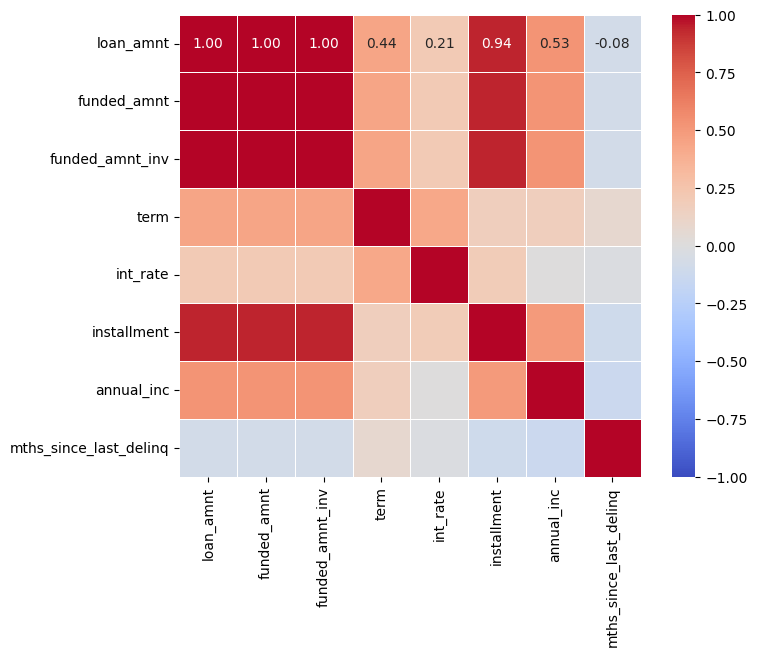

In [168]:
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt='.2f', square=True)

# From the heatmap and crelation amtrix we can observe that there is high corelation between below variables 

1. Loan and Installment
2. Loan and Funded amount
3. Term has medium corelation with Interest rate
4. Months since last delinquent has 0 or negative corelation , which was expected
5. One final check would be to check the ""condition" of corelation matrix. if this number is greater than 30 then variables are multi collinear. 

### Condition Number Definition

$$ \\
The condition \ number (\kappa(A)) of a matrix (A) is defined as the ratio of the largest singular value (sigma_{text{max}}) to the smallest singular value (sigma_{\text{min}}):
$$

$$ \\
[
kappa(A) = \frac{sigma_{text{max}}}{sigma_{text{min}}}
]
$$

$$ \\
Where : 
- (sigma_{text{max}}) is the largest singular value of (A) 
- (sigma_{text{min}}) is the smallest singular value of (A)
$$


### Singular Value Decomposition (SVD)

The **Singular Value Decomposition (SVD)** of a matrix \( A \) is:

$$ \\
[
A = U \Sigma V^T
]
$$

$$ \\
Where:
- ( U ) and ( V ) are orthogonal matrices (containing the left and right singular vectors),
- ( \Sigma ) is a diagonal matrix containing the singular values \( \sigma_1, \sigma_2, \dots, \sigma_n ) along its diagonal.
$$

The condition number can then be written as:

$$ \\
[
\kappa(A) = \frac{\sigma_1}{\sigma_n}
]
$$


In [153]:
# check condition , number  is 1.15 which is lower than 30 depicting lower multicollenearity 
condition = cond(corr_matrix)

In [80]:
# best value is the average within the threshold of portfolio term requirements therefore using lnd_avg as final dataset 
print(m_del_avg,m_del_min,m_del_max,m_del_med,id_knn1)

41.529661016949156 1 118 36.0 41.52966101694915


In [81]:
# rounding up
lnd_avg = lnd_avg.withColumn('mths_since_last_delinq',F.ceil(lnd_avg.mths_since_last_delinq))

In [156]:
lnd_avg.shape()

(832, 75)

In [ ]:
# dd = dd.select(['id','first_time','mat_time','balance_time','LTV_time','interest_rate_time','hpi_time','gdp_time','balance_orig_time','default_time'])

In [82]:
dd = dd.withColumnRenamed('interest_rate_time','int_rate_time')

In [83]:
lnd_avg = lnd_avg.withColumn('balance_time',(lnd_avg.total_rec_prncp + lnd_avg.total_rec_int + lnd_avg.total_rec_late_fee + lnd_avg.recoveries))

Since there are no LTV , HPI and GDP ratios in loan dataset therefore replacing them with best fit figures from dd_lgd_ead dataset. Using Iterative Imputer to maintain the same distribution for the said variables.

Bayesian ridge method is employed since the data shows linearity(as shown above in graphs) . Bayesian ridge uses linear regression to impute the missing values based on Normality and linear assumptions in data 

Given a dataset where missing values are present in a feature y , we model the data using a linear regression model with a Gaussian likelihood and Gaussian prior on the coefficients.

The linear regression model can be written as:
$$ \\
[
y = X \beta +  \epsilon
] 
$$


where:
   - ($y$) is the target variable (the feature to be imputed),    
   - ($X$) is the matrix of input features (other variables in the dataset),
   - ($beta$) is the vector of regression coefficients,
   - ($epsilon \sim \mathcal{N}(0, \sigma^2)$) is the error term, assumed to be normally distributed with mean zero and variance \( \sigma^2 \).



We assume **Gaussian priors** on the coefficients \( $beta$) and **Inverse Gamma priors** on the noise variance \( $sigma^2$):

$$ \\
[
\beta \sim \mathcal{N}(0, \lambda^{-1} I)
]
$$

where \( $lambda$) is the regularization parameter, and \( $I$) is the identity matrix. For the noise variance:

$$ \\
[
\sigma^2 \sim \text{InvGamma}(a, b)
]
$$


where \( $a$) and \( $b$) are the shape and scale parameters of the Inverse Gamma distribution.




The posterior distribution of \( $beta$) given the data is:
$$ \\
[
p(\beta | X, y) = \mathcal{N}(\hat{\beta}, \Sigma_{\beta})
]
$$

where:
$$ \\
[
\hat{\beta} = (X^T X + \lambda I)^{-1} X^T y
]
$$
is the **maximum a posteriori (MAP) estimate** of the coefficients, and

$$ \\
[
\Sigma_{\beta} = (X^T X + \lambda I)^{-1}
]
$$

is the **posterior covariance matrix** of \( $beta$).



For imputing missing values in the target variable \( y_{\text{missing}} \), we use the following prediction equation:
$$ \\
[
y_{\text{missing}} = X_{\text{missing}} \hat{\beta}
]
$$

where:
 - ($X_{\text{missing}} $) is the row vector for the feature with missing values (i.e., the values of other features in the same row),
 - ( $\hat{\beta}$) is the estimated regression coefficients.


In [84]:
lnd_avg = lnd_avg.withColumn('default_time',F.lit(1))

In [85]:
lnd_avg_p = lnd_avg.toPandas()

In [86]:
imp = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

lnd_avg_p['LTV_time'] = imp.fit_transform(lnd_avg_p[['dti','revol_util']])[:, 0]
lnd_avg_p['hpi_time'] = imp.fit_transform(lnd_avg_p[['int_rate','dti']])[:, 0]
lnd_avg_p['gdp_time'] = imp.fit_transform(lnd_avg_p[['revol_util','dti']])[:, 0]

In [87]:
lnd_avg_p[['gdp_time','LTV_time','hpi_time']].head(10)

,gdp_time,LTV_time,hpi_time
0,86.7,7.82,17.27
1,40.9,21.07,14.27
2,28.6,19.78,15.99
3,80.5,5.71,20.99
4,25.8,3.43,15.99
5,93.7,20.52,13.43
6,75.9,20.76,15.28
7,87.0,6.94,12.23
8,13.9,2.70,9.99
9,35.2,13.02,21.48


Text(0.5, 1.0, 'HPI Distribution')

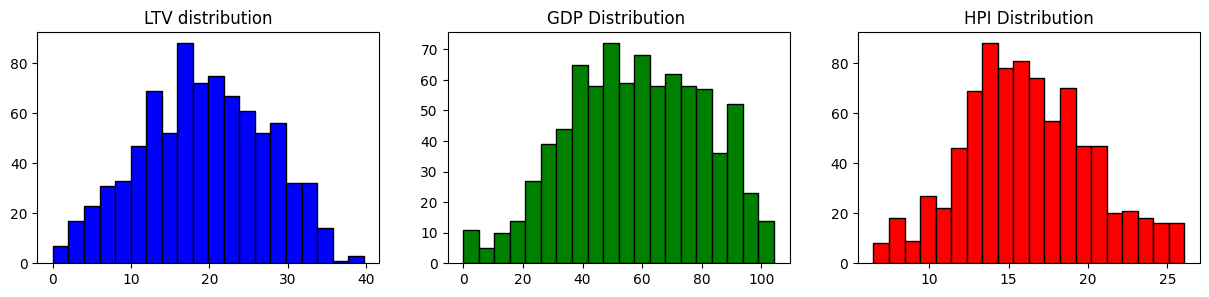

In [242]:
# check for trending of 3 newly created columns 
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

axes[0].hist(lnd_avg_p['LTV_time'], bins=20, color='blue', edgecolor='black')
axes[0].set_title('LTV distribution')

axes[1].hist(lnd_avg_p['gdp_time'], bins=20, color='green', edgecolor='black')
axes[1].set_title('GDP Distribution ')

axes[2].hist(lnd_avg_p['hpi_time'], bins=20, color='red', edgecolor='black')
axes[2].set_title('HPI Distribution')

In [102]:
lnd_avg_p = lnd_avg_p.rename(columns={'funded_amnt' : 'balance_orig_time','int_rate' : 'int_rate_time','mths_since_last_delinq':'first_time','term':'mat_time'})
lnd_avg_p['EAD'] = lnd_avg_p['balance_time']
lnd_avg_p['LGD'] = (lnd_avg_p['balance_orig_time'] - lnd_avg_p['balance_time'])/lnd_avg_p['EAD']

In [107]:
print(len(lnd_avg_p[lnd_avg_p.LGD < 0]))

45


In [108]:
select_col = ['id','first_time','mat_time','balance_time','LTV_time','int_rate_time','hpi_time','gdp_time','balance_orig_time','default_time','EAD','LGD']
lnd_avg_p = lnd_avg_p[select_col]

In [ ]:
# lnd_avg = lnd_avg.select(['id'\
#                           ,'first_time'\
#                           ,'mat_time'\
#                           ,'balance_time'\
#                           ,'LTV_time'\
#                           ,'int_rate_time'\
#                           ,'hpi_time'\
#                           ,'gdp_time'\
#                           ,'balance_orig_time'\
#                           ,'default_time'\
#                           ,'EAD'\
#                           ,'LGD'])


In [109]:
dd_lgd_ead_p = dd_lgd_ead.toPandas() 

In [112]:
dd_lgd_ead_p.dtypes

id                     int32
first_time             int32
mat_time               int32
balance_time         float64
balance_orig_time    float64
EAD                  float64
hpi_time             float64
gdp_time             float64
LTV_time             float64
int_rate_time        float64
default_time           int32
LGD                  float64
dtype: object

In [115]:
lnd_avg_p.dtypes

id                     int32
first_time             int64
mat_time             float32
balance_time         float64
LTV_time             float64
int_rate_time        float64
hpi_time             float64
gdp_time             float64
balance_orig_time      int32
default_time           int32
EAD                  float64
LGD                  float64
dtype: object

In [119]:
df_list = pd.concat([lnd_avg_p,dd_lgd_ead_p],axis=0,ignore_index=True)

In [ ]:
# # Conctenate overall default and loan default dataset for processed dataset that will be used for Survival Analysis. The below code  
# is used to concatenate spark dataframe . The data analysis and imputation was done on python dataframe and not spark.
# df_list = [lnd_avg_p,dd_lgd_ead]
# df = reduce(F.DataFrame.unionByName,df_list)

In [ ]:
#df.select(df.columns[:20]).show(3)

In [120]:
# checking for total sum of missing values , spark and python  code 
# df.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(),c)).alias(c) for c in df.columns]).show()
df_list.isna().sum()

id                   0
first_time           0
mat_time             0
balance_time         0
LTV_time             1
int_rate_time        0
hpi_time             0
gdp_time             0
balance_orig_time    0
default_time         0
EAD                  0
LGD                  0
dtype: int64

# Steps for Model building 
1. Understand the data distribution ( completed in above steps)
2. Apply the Survival Function

Not performing normalization of data since survival doesnt require normalization . Also this data doesnt have continous variables therefore there is no need for one hot encoding . Even though normalization is always good to perform for any model but this is more applicable for regression based models such as Lasso, Ridge and Elastic regression because the penalty coeffecients are same for all variables , meaning they dont change as per the variables error distance from the regression line.

In [121]:
df_list.describe()

,id,first_time,mat_time,balance_time,LTV_time,int_rate_time,hpi_time,gdp_time,balance_orig_time,default_time,EAD,LGD
count,2.357000e+03,2357.000000,2357.000000,2.357000e+03,2356.000000,2357.000000,2357.000000,2357.000000,2.357000e+03,2357.0,2.357000e+03,2357.000000
mean,6.236791e+06,31.491303,108.482393,1.629932e+05,69.762535,10.599460,119.554268,20.770941,1.660720e+05,1.0,1.629932e+05,0.910354
std,1.037519e+07,15.551397,48.140810,1.831538e+05,41.406554,5.019633,79.098758,30.640992,1.792339e+05,0.0,1.831538e+05,0.694556
min,9.000000e+00,1.000000,36.000000,4.430400e+02,0.000000,2.000000,6.490000,-4.146711,0.000000e+00,1.0,4.430400e+02,-0.258704
25%,2.013300e+04,25.000000,60.000000,9.154820e+03,23.967500,7.125000,18.240000,0.892996,1.935000e+04,1.0,9.154820e+03,0.476196
50%,3.817400e+04,28.000000,141.000000,1.117962e+05,82.367041,8.875000,154.940000,2.274218,1.147500e+05,1.0,1.117962e+05,0.812312
75%,1.055772e+07,41.000000,146.000000,2.520000e+05,105.913932,13.980000,180.520000,43.500000,2.520000e+05,1.0,2.520000e+05,1.035661
max,3.783081e+07,118.000000,228.000000,1.518109e+06,155.613265,26.060000,226.290000,104.200000,1.440000e+06,1.0,1.518109e+06,4.321413


In [ ]:
# # manipluate the dataset for LTV , HPI and gdp columns
# coltofill = ['LTV_time','hpi_time','gdp_time']
# for col in coltofill:
#     dfp[col].fillna(dfp[col].mean(),inplace=True)

In [122]:
# make the target variables and perfrom corelation(for linear relationships) and Bayesian Copula for non-linear relationships 
df_list['recovery_rate'] = df_list['balance_time']/df_list['balance_orig_time']

In [123]:
# Survival needs to be done only on positive cash flows between 0 and 1 
dfp_final = df_list[(df_list['recovery_rate'] >= 0) & (df_list['recovery_rate'] <= 1)]

In [124]:
dfp_final.value_counts()

id        first_time  mat_time  balance_time  LTV_time    int_rate_time  hpi_time  gdp_time    balance_orig_time  default_time  EAD        LGD       recovery_rate
72        33          141.0     127858.64     101.403077  7.000          153.35    -4.146711   129500.0           1             127858.64  1.000000  0.987325         1
6522104   41          36.0      12123.18      19.360000   15.880         15.88      75.500000  14400.0            1             12123.18   0.187807  0.841888         1
6714785   41          36.0      10569.00      14.100000   11.550         11.55      69.300000  13350.0            1             10569.00   0.263128  0.791685         1
6706615   41          60.0      12702.54      34.550000   24.890         24.89      77.100000  18075.0            1             12702.54   0.422944  0.702768         1
6704710   41          60.0      13969.98      16.420000   15.880         15.88      57.900000  24000.0            1             13969.98   0.717970  0.582082        

# Performing Logistic Regession using below of the 2 mthods 

1. Linear Regression : Deriving the LGD with Predicted variables and getting the coeffecients which are best suited
2. Logistic Regerssion : Steps to logistic regression ;
    a.Decide the threshold , ususally between 0.1 to 0.9
    b.Finalize the best beta coeffecient using Newton Raphson algorithm 
    c.Get LGD predictions based on best beta coefficient 

In [ ]:
# Normalizing the dataset before applying regression 
lr_minmax = Pipeline([
    ('scaler',MinMaxScaler()),
     ])

In [ ]:
lr_standard = Pipeline([
    ('scaler',StandardScaler()),
     ])